# Data source: 70k+ Job Applicants Data (Human Resource)

### Link: https://www.kaggle.com/datasets/ayushtankha/70k-job-applicants-data-human-resource/data

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


## Load and Clean Data

In [7]:
# Replace with your CSV file path
df = pd.read_csv("stackoverflow_full.csv")

df.head()

# cleaning data
df = df.dropna(subset=["Age", "ComputerSkills", "Employed"])

# Print basic dataset info
print("Total rows:", len(df))
print("Employment status values:", df["Employed"].unique())

Total rows: 73462
Employment status values: [0 1]


## Plot 1: Age Distribution

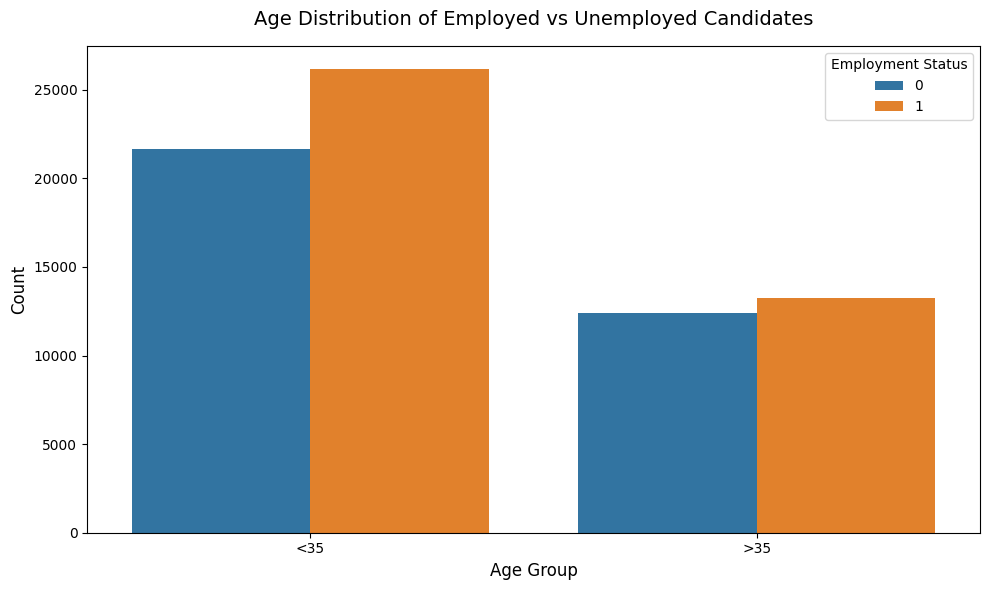

In [8]:
plt.figure(figsize=(10, 6))

# Grouped bar chart
sns.countplot(
    x="Age",
    hue="Employed",
    data=df,
    palette=["#1f77b4", "#ff7f0e"]
)

# English titles and labels
plt.title("Age Distribution of Employed vs Unemployed Candidates", fontsize=14, pad=15)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="Employment Status")
plt.tight_layout()
plt.show()

## Plot 2: Employment Rate by Computer Skills

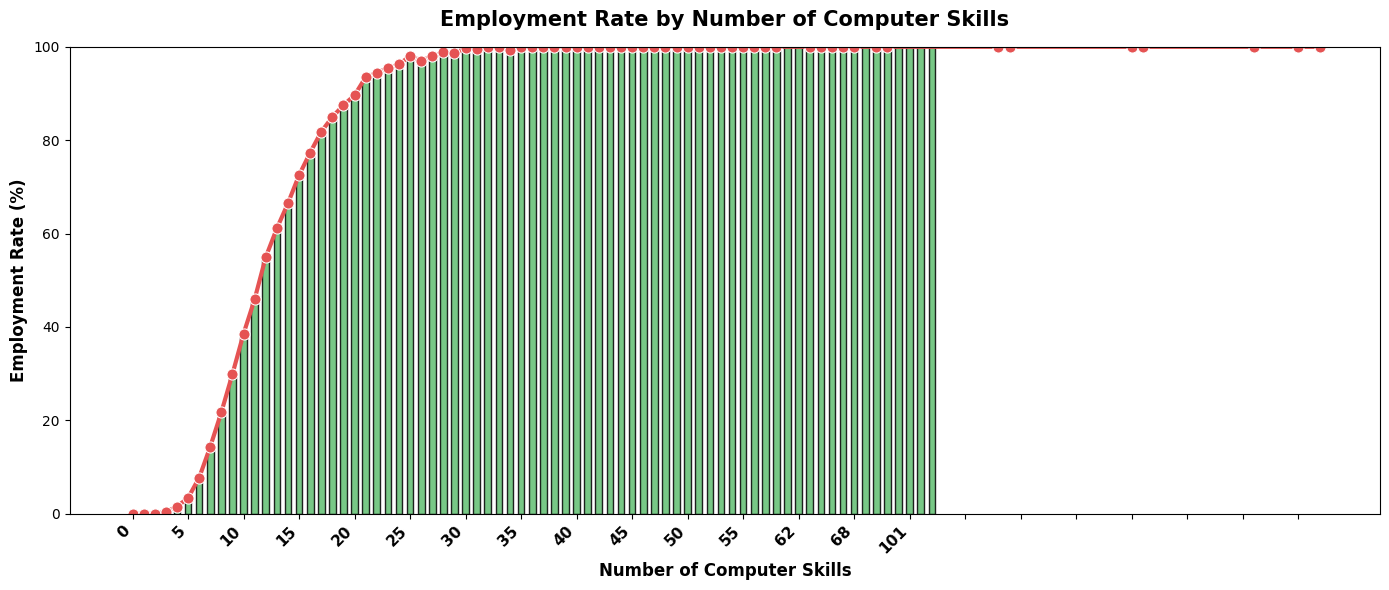

In [16]:
# Calculate employment rate
skill_stats = df.groupby("ComputerSkills")["Employed"].agg(
    total="count", employed_sum="sum"
)
skill_stats["employment_rate"] = (skill_stats["employed_sum"] / skill_stats["total"] * 100).round(2)
skill_stats = skill_stats.reset_index()

# Plot
plt.figure(figsize=(14, 6))

ax = sns.barplot(
    x="ComputerSkills", y="employment_rate", data=skill_stats,
    color="#51cf66", alpha=0.85, edgecolor="black", linewidth=1,
    width=0.6
)

sns.lineplot(
    x="ComputerSkills", y="employment_rate", data=skill_stats,
    marker="o", color="#e55353", linewidth=3, markersize=8
)

max_skill = int(skill_stats["ComputerSkills"].max())
plt.xticks(
    ticks=range(0, max_skill + 1, 5),
    rotation=45,
    ha='right',
    fontsize=11,
    weight='bold'
)

# Labels
plt.title("Employment Rate by Number of Computer Skills", fontsize=15, weight="bold", pad=15)
plt.xlabel("Number of Computer Skills", fontsize=12, weight="bold")
plt.ylabel("Employment Rate (%)", fontsize=12, weight="bold")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

###  Correlation test

In [ ]:
import statsmodels.api as sm
from scipy.stats import chi2_contingency, pearsonr
from statsmodels.formula.api import logit

In [18]:
skill_summary = df.groupby("ComputerSkills")["Employed"].agg(
    total="count",
    employed="sum",
    employment_rate=lambda x: round(x.mean() * 100, 2)
).reset_index()

print("=" * 70)
print("Descriptive Statistics: Employment Rate by Computer Skills")
print("=" * 70)
print(skill_summary.head(15))

Descriptive Statistics: Employment Rate by Computer Skills
    ComputerSkills  total  employed  employment_rate
0                0     63         0             0.00
1                1    370         0             0.00
2                2   1012         0             0.00
3                3   1557         6             0.39
4                4   2152        33             1.53
5                5   2693        91             3.38
6                6   3147       243             7.72
7                7   3636       522            14.36
8                8   4005       871            21.75
9                9   4236      1268            29.93
10              10   4551      1755            38.56
11              11   4656      2140            45.96
12              12   4524      2487            54.97
13              13   4483      2740            61.12
14              14   4329      2879            66.50


In [19]:
corr, p_corr = pearsonr(df["ComputerSkills"], df["Employed"])
print("\n" + "=" * 70)
print("Pearson Correlation (Point-Biserial)")
print("=" * 70)
print(f"Correlation coefficient: {corr:.4f}")
print(f"P-value:                 {p_corr:.8f}")

if p_corr < 0.05:
    print("Result: Significant positive correlation between skills and employment.")
else:
    print("Result: No significant correlation.")


Pearson Correlation (Point-Biserial)
Correlation coefficient: 0.5855
P-value:                 0.00000000
Result: Significant positive correlation between skills and employment.


### Chi-square test of independence

In [20]:
df["skill_group"] = pd.qcut(
    df["ComputerSkills"], q=4,
    labels=["Low", "Moderate", "High", "Very High"]
)
crosstab = pd.crosstab(df["skill_group"], df["Employed"])

chi2, p_chi2, dof, expected = chi2_contingency(crosstab)
print("\n" + "=" * 70)
print("Chi-Square Test of Independence")
print("=" * 70)
print(crosstab)
print(f"\nChi2:  {chi2:.4f}")
print(f"P-val: {p_chi2:.8f}")

if p_chi2 < 0.05:
    print("Result: Skill groups and employment are significantly associated.")
else:
    print("Result: No significant association.")


Chi-Square Test of Independence
Employed         0      1
skill_group              
Low          16869   1766
Moderate     12060  10390
High          3876  10956
Very High     1265  16280

Chi2:  28357.3813
P-val: 0.00000000
Result: Skill groups and employment are significantly associated.


### Logistic regression (formal significance test)

In [25]:
model = logit("Employed ~ ComputerSkills", data=df).fit(disp=0)

print("\n" + "=" * 70)
print("Logistic Regression: Effect of ComputerSkills on Employment")
print("=" * 70)
print(model.params)
print(f"\nP-value for ComputerSkills: {model.pvalues['ComputerSkills']:.8f}")

odds_ratio = np.exp(model.params["ComputerSkills"])

if model.pvalues["ComputerSkills"] < 0.05:
    print("\nConclusion: ComputerSkills has a statistically significant positive effect on employment rate.")
    print(f"Each additional skill increases employment odds by {(odds_ratio - 1) * 100:.1f}%.")
else:
    print("\nConclusion: ComputerSkills does NOT significantly affect employment rate.")


Logistic Regression: Effect of ComputerSkills on Employment
Intercept        -3.940439
ComputerSkills    0.327119
dtype: float64

P-value for ComputerSkills: 0.00000000

Conclusion: ComputerSkills has a statistically significant positive effect on employment rate.
Each additional skill increases employment odds by 38.7%.


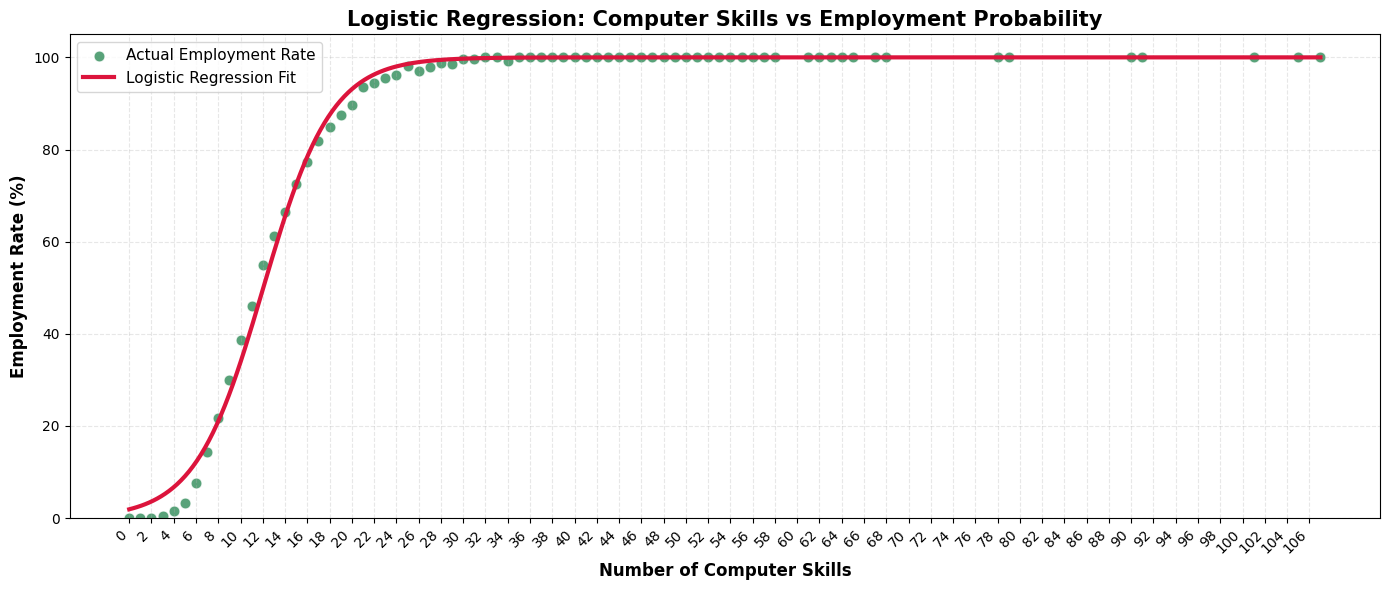

In [29]:
# Create Smooth Logistic Curve
x_min = df["ComputerSkills"].min()
x_max = df["ComputerSkills"].max()
x_range = np.linspace(x_min, x_max, 300)  # smooth line
y_pred = model.predict(pd.DataFrame({"ComputerSkills": x_range})) * 100  # convert to %


plt.figure(figsize=(14, 6))

# Plot real employment rate (points)
sns.scatterplot(
    x="ComputerSkills", y="employment_rate", data=skill_stats,
    color="#2e8b57", s=60, alpha=0.8, label="Actual Employment Rate"
)

# Plot logistic regression curve
plt.plot(
    x_range, y_pred,
    color="#dc143c", linewidth=3, label="Logistic Regression Fit"
)

# Fix X-axis (no overlap, clean)
plt.xticks(np.arange(0, x_max + 1, 2), rotation=45, ha="right", fontsize=10)

# Labels
plt.title("Logistic Regression: Computer Skills vs Employment Probability", fontsize=15, weight="bold")
plt.xlabel("Number of Computer Skills", fontsize=12, weight="bold")
plt.ylabel("Employment Rate (%)", fontsize=12, weight="bold")
plt.ylim(0, 105)
plt.legend(fontsize=11)
plt.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()